# 0. Preparation

In [1]:
# 安装依赖
# !pip install -qU peft accelerate datasets einops ipywidgets

In [2]:
import os
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
os.environ['HF_HUB_ENDPOINT'] = 'https://hf-mirror.com'
import copy
import json
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from tqdm import tqdm
from typing import List
from einops import rearrange
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from transformers import AutoConfig, AutoTokenizer, AutoModel, AutoModelForCausalLM

device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype = torch.bfloat16 if device != 'cpu' and torch.cuda.is_bf16_supported() else torch.float32
print(f'device: {device}\ndtype: {dtype}')

/environment/miniconda3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda
dtype: torch.bfloat16


# 1. LoRA Dry Run

先使用一个极小参数的 llama 模型 dry run，验证 lora 是否正常工作。

In [3]:
config = AutoConfig.for_model('llama')  # 获取LLaMA架构的默认配置模板
config.hidden_size = 24  # 隐藏层维度
config.intermediate_size = config.hidden_size * 4  # 中间层维度（FFN层）
config.num_attention_heads = 4  # 注意力头数量
config.num_hidden_layers = 4  # Transformer层数
config.num_key_value_heads = 2  # 键值头数量（GQA分组查询注意力）
config.vocab_size = 128  # 词表大小
config.head_dim = config.hidden_size // config.num_attention_heads  # 每个头的维度（新版Transformers需要显式指定）

In [4]:
raw_model = AutoModel.from_config(config)
raw_model

LlamaModel(
  (embed_tokens): Embedding(128, 24)
  (layers): ModuleList(
    (0-3): 4 x LlamaDecoderLayer(
      (self_attn): LlamaAttention(
        (q_proj): Linear(in_features=24, out_features=24, bias=False)
        (k_proj): Linear(in_features=24, out_features=12, bias=False)
        (v_proj): Linear(in_features=24, out_features=12, bias=False)
        (o_proj): Linear(in_features=24, out_features=24, bias=False)
      )
      (mlp): LlamaMLP(
        (gate_proj): Linear(in_features=24, out_features=96, bias=False)
        (up_proj): Linear(in_features=24, out_features=96, bias=False)
        (down_proj): Linear(in_features=96, out_features=24, bias=False)
        (act_fn): SiLUActivation()
      )
      (input_layernorm): LlamaRMSNorm((24,), eps=1e-06)
      (post_attention_layernorm): LlamaRMSNorm((24,), eps=1e-06)
    )
  )
  (norm): LlamaRMSNorm((24,), eps=1e-06)
  (rotary_emb): LlamaRotaryEmbedding()
)

## LoRA 类定义

**LoRA forward：**
$$
W = W_0 + \Delta W
  = W_0 + \frac{\alpha}{r}BA
$$

$$
\begin{aligned}
\mathbf{y} &= W_0\mathbf{x} + \Delta W \mathbf{x} \\[4pt]
           &= W_0\mathbf{x} + \frac{\alpha}{r} \cdot BA \cdot \mathbf{x}
\end{aligned}
$$

矩阵分析：
$$
\begin{aligned}
\mathbf{x} &\in \mathbb{R}^{\,\texttt{batch} \times \texttt{seq} \times d_{\text{in}}} \\[4pt]
A &\in \mathbb{R}^{\,r \times d_{\text{in}}},
\quad
B \in \mathbb{R}^{\,d_{\text{out}} \times r} \\[8pt]
\mathbf{h} &= \mathbf{x} \cdot A^{\top}
            \in \mathbb{R}^{\,\texttt{batch} \times \texttt{seq} \times r} \\[4pt]
\Delta\mathbf{y} &= \mathbf{h} \cdot B^{\top}
                  = \mathbf{x} \cdot A^{\top} \cdot B^{\top}
                  \in \mathbb{R}^{\,\texttt{batch} \times \texttt{seq} \times d_{\text{out}}} \\[4pt]
\mathbf{y} &= W_0\mathbf{x} + \frac{\alpha}{r} \cdot \Delta\mathbf{y}
            \in \mathbb{R}^{\,\texttt{batch} \times \texttt{seq} \times d_{\text{out}}}
\end{aligned}
$$

In [5]:
class LoraLinear(nn.Module):
    def __init__(
        self,
        base_layer: nn.Linear,      # 原来的线性层
        r: int = 8,                 # lora rank
        alpha: int = 16,            # lora alpha
        dropout_p: float = 0.0,     # lora dropout
        test_mode: bool = False,    # 测试模式，用于控制 lora_B 是否为全零
    ):
        super(LoraLinear, self).__init__() # super 找到 LoraLinear 的父类（nn.Module）的 __init__ 方法
        self.base_layer = copy.deepcopy(base_layer) # 把传入的原始线性层拷贝一份存起来，这样修改 LoRA 层不会影响原始模型
        self.r = r
        self.alpha = alpha
        self.dropout = nn.Dropout(dropout_p)

        # 定义 lora_A 和 lora_B 为 Parameter
        # 下投影矩阵 A
        self.lora_A = nn.Parameter(torch.empty((r, base_layer.in_features), dtype=base_layer.weight.dtype))
        # 上投影矩阵 B
        self.lora_B = nn.Parameter(torch.empty((base_layer.out_features, r), dtype=base_layer.weight.dtype))

        # 初始化 lora 矩阵
        nn.init.normal_(self.lora_A, mean=0.0, std=0.02)
        if test_mode:
            nn.init.normal_(self.lora_B, mean=0.0, std=0.02)
        else:
            nn.init.zeros_(self.lora_B)

        # 冻结原来的层的参数
        for param in self.base_layer.parameters():
            param.requires_grad = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        scaling = float(self.alpha) / float(self.r)     # lora 缩放系数
        lora_adjustment = F.linear(self.dropout(x), self.lora_A) # linear 会计算 h = x @ lora_A.T
        lora_adjustment = F.linear(lora_adjustment, self.lora_B) # linear 会计算 lora_adjustment = h @ lora_B.T
        return self.base_layer(x) + lora_adjustment * scaling

## 替换 LoRA 部分

In [6]:
def replace_linear_with_lora(
    module: nn.Module,
    r: int = 8,
    alpha: int = 16,
    dropout_p: float = 0.0,
    embed_requires_grad: bool = False,      # embedding 层是否训练
    norm_requires_grad: bool = False,       # norm 层是否训练
    head_requires_grad: bool = False,       # lm_head 层是否训练（Causal LM才有）
    test_mode: bool = False,                # 测试模式，用于控制 lora_B 是否为全零
):
    """
    找到 module 中所有线性层并递归替换
    """
    for name, child in module.named_children():
        # 先处理额外的层，lm_head 也是 linear，所以先处理
        if any(s in name for s in ['embed', 'norm', 'lm_head']):
            requires_grad = embed_requires_grad if 'embed' in name \
                            else norm_requires_grad if 'norm' in name \
                            else head_requires_grad
            for param in child.parameters():
                param.requires_grad = requires_grad
        # 替换所有线性层，QLoRA 做法
        elif isinstance(child, nn.Linear):
            lora_linear = LoraLinear(child, r=r, alpha=alpha, dropout_p=dropout_p, test_mode=test_mode)
            setattr(module, name, lora_linear)
        # 递归向下替换
        else:
            replace_linear_with_lora(
                child, r, alpha, dropout_p,
                embed_requires_grad, norm_requires_grad, head_requires_grad,
                test_mode=test_mode
            )

In [7]:
def unload_lora(module: nn.Module, adapter_name: str = 'adapter'):
    """
    卸载 lora 参数，并将原模型恢复至加载 lora 前的样子
    """
    lora_parameters = {} # 准备一个空字典，用来收集所有 LoRA 层的参数
    def search_lora_linear(module: nn.Module, prefix: List[str]):
        """
        递归搜索模块中的所有 LoRA 层，将参数保存到 lora_parameters 中
        """
        for name, child in module.named_children():
            new_prefix = prefix + [name]
            if isinstance(child, LoraLinear):
                # 保存 lora 参数
                lora_parameters['.'.join(new_prefix)] = {
                    "lora_A_weight": child.lora_A.data.cpu(),
                    "lora_B_weight": child.lora_B.data.cpu(),
                    "r": child.r,
                    "alpha": child.alpha,
                    "dropout_p": child.dropout.p,
                }
                setattr(module, name, child.base_layer)
            else:
                search_lora_linear(child, new_prefix)

    search_lora_linear(module, [])
    # 解冻原模型
    for name, param in module.named_parameters():
        param.requires_grad = True

    torch.save(lora_parameters, f"{adapter_name}.pt") # 将 lora 参数保存为 .pt 文件

In [8]:
def load_lora(module: nn.Module, adapter_name: str = 'adapter'):
    """
    从 .pt 文件中加载 lora 参数
    """
    lora_parameters = torch.load(f"{adapter_name}.pt")

    for name, lora_params in lora_parameters.items():
        child = dict(module.named_modules())[name]
        if isinstance(child, nn.Linear):
            lora_linear = LoraLinear(child, lora_params['r'], lora_params['alpha'], lora_params['dropout_p'])
            lora_linear.lora_A.data = lora_params["lora_A_weight"].to(lora_linear.lora_A.device)
            lora_linear.lora_B.data = lora_params["lora_B_weight"].to(lora_linear.lora_B.device)

            # 名称示例：layers.0.self_attn.q_proj
            # 根据名称循环找到所需 module
            parts = name.split(".")
            obj = module
            for part in parts[:-1]:  # 不包括最后一级
                obj = getattr(obj, part)
            setattr(obj, parts[-1], lora_linear)

    # 恢复原来的冻结方式，这里简单地除了 lora 全冻结
    for name, param in module.named_parameters():
        if any(s in name for s in ['embed', 'norm', 'lm_head']):
            param.requires_grad = False

## LoRA 尝试

In [9]:
def print_trainable_parameters(model: nn.Module):
    """
    打印可训练参数，和 PeftModel 的方法类似
    """
    total_params = sum(p.numel() for p in model.parameters()) # 计算模型的所有参数数量
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad) # 计算可训练参数数量
    trainable_percentage = 100 * trainable_params / total_params # 计算可训练参数占比

    print(f"trainable params: {trainable_params:,} || all params: {total_params:,} || trainable%: {trainable_percentage:.4f}")

LoRA 前的参数情况：

In [10]:
print_trainable_parameters(raw_model)

trainable params: 37,848 || all params: 37,848 || trainable%: 100.0000


LoRA 后的参数情况：

In [11]:
lora_model = copy.deepcopy(raw_model)
replace_linear_with_lora(lora_model)
print_trainable_parameters(lora_model)

trainable params: 16,896 || all params: 54,744 || trainable%: 30.8637


测试 load 和 unload：

In [12]:
# 创建一个测试 tensor
bsz = 2 # 批量大小
seq_len = 8 # 序列长度
test_tensor = torch.randint(0, config.vocab_size, (bsz, seq_len))
# raw_model(test_tensor)    原始模型输出
# lora_model(test_tensor)   带 LoRA 输出

In [13]:
# 开测试模式，让 BA 非零
lora_model = copy.deepcopy(raw_model)
replace_linear_with_lora(lora_model, test_mode=True)

In [14]:
# 原模型的前向结果
raw_model.eval() # .eval() 把模型内部所有子模块的 training 标志全部设为 False
print_trainable_parameters(raw_model)   # 检查参数和可训练情况
raw_res = raw_model(test_tensor).last_hidden_state

trainable params: 37,848 || all params: 37,848 || trainable%: 100.0000


In [15]:
# 第一次直接初始化 lora 的前向结果
lora_model.eval()
print_trainable_parameters(lora_model)  # 检查参数和可训练情况
before_unload_res = lora_model(test_tensor).last_hidden_state

trainable params: 16,896 || all params: 54,744 || trainable%: 30.8637


In [16]:
# 卸载 lora 后的前向结果
unload_lora(lora_model)
lora_model.eval()
print_trainable_parameters(lora_model)  # 检查参数和可训练情况
unload_res = lora_model(test_tensor).last_hidden_state

trainable params: 37,848 || all params: 37,848 || trainable%: 100.0000


In [17]:
# 重新装载 lora 后的前向结果
load_lora(lora_model)
lora_model.eval()
print_trainable_parameters(lora_model)  # 检查参数和可训练情况
load_res = lora_model(test_tensor).last_hidden_state

trainable params: 16,896 || all params: 54,744 || trainable%: 30.8637


In [18]:
print(torch.allclose(raw_res, unload_res, atol=1e-6))           # 应为 True：卸载 LoRA 后模型回到原始状态
print(torch.allclose(before_unload_res, load_res, atol=1e-6))   # 应为 True：重新加载 LoRA 后和卸载前完全一致
print(torch.allclose(raw_res, load_res, atol=1e-6))             # 应为 False：test_mode 让 BA 非零，确实改变了模型输出

True
True
False


# 2. LoRA 实战

## 模型

模型选择 [Qwen/Qwen1.5-0.5B](https://huggingface.co/Qwen/Qwen1.5-0.5B)，表现不够强，方便观察 LoRA 效果。<br>
数据集选择 [bio-nlp-umass/bioinstruct](https://huggingface.co/datasets/bio-nlp-umass/bioinstruct)，这是一个生物医学指令数据集，用于微调模型。

In [19]:
model_name_or_path = 'Qwen/Qwen1.5-0.5B'
data_name_or_path = 'bio-nlp-umass/bioinstruct'

In [20]:
tokenizer = AutoTokenizer.from_pretrained(model_name_or_path) # 从 Hugging Face 自动加载与模型匹配的分词器，会自动找到对应的 tokenizer 配置
tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = 'left'

model = AutoModelForCausalLM.from_pretrained(model_name_or_path, dtype=dtype).to(device)
# AutoModelForCausalLM：Transformers 提供的自动模型类，用于加载因果语言模型（Causal Language Model），例如 Qwen、LLaMA、GPT。因果语言模型根据前面的 Token 预测下一个 Token，适用于文本生成和对话任务。
# .from_pretrained(model_name_or_path)：从 Hugging Face Hub 或本地目录加载预训练模型。

Loading weights: 100%|██████████| 291/291 [00:00<00:00, 4114.45it/s]


dtype 指定模型权重的数据类型：
```python
dtype = (
    torch.bfloat16
    if device != "cpu" and torch.cuda.is_bf16_supported()
    else torch.float32
)
```
- BF16：16位浮点数
- BF32：32位浮点数

- GPU 支持 BF16：使用 torch.bfloat16 ，减少显存占用并提高计算速度；
- 使用 CPU 或 GPU 不支持 BF16：使用 torch.float32 ，兼容性更好。

例如，0.5B 参数模型仅计算参数权重时：
- FP32 大约占 0.5B × 4 Bytes ≈ 2 GB ；<br>
0.5B × 4 Bytes = 2B Bytes <br>
1B = 1,000,000,000 ≈ $1024^3$，**即 `1 Billion ≈ 1G`** <br>
故 2B Bytes ≈ 2 × $1024^3$ Bytes ≈ 2 GB <br>
- BF16 大约占 0.5B × 2 Bytes ≈ 1 GB 。

In [21]:
# 获取 lora model
replace_linear_with_lora(model, r=8, alpha=16, dropout_p=0.0)
model.to(device)

# 查看可训练参数
print_trainable_parameters(model)

trainable params: 3,784,704 || all params: 467,772,416 || trainable%: 0.8091


**关于这里的 model.to(device)：** <br>
<br>
`model = AutoModelForCausalLM.from_pretrained(...).to(device)` 之后，模型已经在 GPU 上了。<br>
但是调用 `replace_linear_with_lora(...)` 时，创建的 lora_A 和 lora_B 默认设备是 CPU。<br>
```python
self.lora_A = nn.Parameter(torch.empty((r, in_features), ...))   # ← torch.empty()默认在 CPU 创建！
self.lora_B = nn.Parameter(torch.empty((out_features, r), ...))  # ← torch.empty()默认在 CPU 创建！
```
所以执行完 replace_linear_with_lora 之后
```
model 的参数分布：
  ├── embed_tokens      → GPU  ✅
  ├── layers            → GPU  ✅
  ├── lora_A（新增的）   → CPU  ❌
  ├── lora_B（新增的）   → CPU  ❌
  └── ...
```
训练时 forward 会做矩阵乘法：`x @ lora_A.T`，PyTorch 不允许 GPU 张量和 CPU 张量之间做运算。<br>

`model.to(device)` 会把模型的 所有参数 （不管原来在哪）都搬到 device （GPU），这就解决了该问题。

## 数据集

In [22]:
# 定义训练数据集
class SFTDataset(Dataset):
    def __init__(self,
        tokenizer: AutoTokenizer,
        data_path: str,
        load_local: bool = False,
        max_len: int = 256,
        split_len: str = '1%',
    ):
        super().__init__() # 调用 PyTorch Dataset 基类初始化
        self.tokenizer = tokenizer

        if load_local:
            # 加载完整数据集
            ds = load_dataset('json', data_dir=data_path, split=f'train[:{split_len}]')
        else:
            # 只取训练集的前 1%，数据量小，适合快速试跑
            ds = load_dataset(data_path, split=f'train[:{split_len}]')
        self.max_len = max_len

        def process_func(example):
            # 提取 instruction、input 和 output
            instruction = example['instruction'].strip()
            input = example['input'].strip()
            output = example['output'].strip()

            # 构造输入模板
            instruction_msg = [
                {"role": "user", "content": (instruction + f"\n{input}") if len(input) > 0 else instruction}
            ]
            
            # apply_chat_template 是 Transformers 提供的方法，根据 Qwen 的聊天模板自动添加特殊 Token
            # 使用 tokenizer 进行分词
            tokenized_instruction = tokenizer.apply_chat_template(instruction_msg,tokenize=True,add_generation_prompt=True,)["input_ids"]
            tokenized_output = tokenizer(output + "<|im_end|>" + f"{tokenizer.eos_token}\n")['input_ids']

            # 截断，最大不超过 max_len
            tokenized_prompt = (tokenized_instruction + tokenized_output)[:self.max_len]

            # 构造 input_ids, attention_mask, labels
            input_ids = tokenized_prompt[:-1]
            attention_mask = [1] * len(input_ids)
            labels = tokenized_prompt[1:]

            # instruction 部分不计算 loss
            instruction_label_len = len(tokenized_instruction) - 1
            labels[:instruction_label_len] = [-100] * instruction_label_len

            return {
                'input_ids': input_ids,
                'attention_mask': attention_mask,
                'labels': labels,
            }

        self.ds = ds.map(
            process_func,
            batched=False,
            remove_columns=ds.column_names,
            desc='Processing dataset',
        )

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, index: int):
        return self.ds[index]

In [23]:
ds = SFTDataset(tokenizer, data_name_or_path, load_local=False) # 这里只取 1% dry run

In [24]:
print(len(ds[0]['input_ids']))
print(len(ds[0]['attention_mask']))
print(len(ds[0]['labels']))

print(tokenizer.decode(ds[0]['input_ids']))
print(ds[0]['attention_mask'])
valid_labels = [token_id for token_id in ds[0]['labels'] if token_id != -100]
print(tokenizer.decode(valid_labels))

79
79
79
<|im_start|>system
You are a helpful assistant<|im_end|>
<|im_start|>user
Identify the main conclusion from the provided medical report excerpt.
The patient's blood test results showed an elevation in liver enzymes, specifically ALT and AST, which suggests potential liver damage. Additionally, the patient's ultrasound showed a fatty liver.<|im_end|>
<|im_start|>assistant
The patient has signs of liver damage and a fatty liver.<|im_end|><|endoftext|>
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
The patient has signs of liver damage and a fatty liver.<|im_end|><|endoftext|>



In [25]:
def collate_fn(batch: List, tokenizer):
    max_len = max(
        max(len(item[k]) for item in batch)
        for k in ['input_ids', 'attention_mask', 'labels']
    )

    input_ids = []
    attention_mask = []
    labels = []

    for item in batch:
        input_id = item['input_ids']
        attention_mask_item = item['attention_mask']
        label = item['labels']

        # 计算填充长度
        pad_len = max_len - len(input_id)
        pad_len_label = max_len - len(label)

        # 左填充
        input_ids.append([tokenizer.eos_token_id] * pad_len + input_id)
        attention_mask.append([0] * pad_len + attention_mask_item)
        labels.append([-100] * pad_len_label + label)

    # 将列表转换为张量
    input_ids = torch.LongTensor(input_ids)
    attention_mask = torch.LongTensor(attention_mask)
    labels = torch.LongTensor(labels)

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels,
    }


## 训练

In [26]:
bsz = 8
lr = 5e-4
num_epochs = 3
logging_steps = 5   # 每 5 步打印一次 loss
max_grad_norm = 1.0 # 梯度裁剪阈值

In [27]:
dataloader = DataLoader(ds, batch_size=bsz, shuffle=True, collate_fn=lambda batch: collate_fn(batch, tokenizer))
# shuffle=True 会随机打乱数据
# collate_fu 告诉 DataLoader 怎么把 bsz 条长度不同的样本拼成一个整齐的张量

In [28]:
optimizer = optim.AdamW(model.parameters(), lr=lr)
# optim.AdamW：Adam 的改进版，权重衰减（weight decay）和自适应学习率分开处理，泛化更好
# model.parameters()：返回模型的所有可训练参数

In [29]:
model.train()

total_loss = 0
total_step = 0
loss_history = []  # 记录每个 logging step 的累计平均 loss
for epoch in range(num_epochs):
    for step, batch in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        logits = outputs.logits
        rearranged_logits = rearrange(logits, 'bsz seq_len vocab_size -> (bsz seq_len) vocab_size')
        rearranged_labels = rearrange(labels, 'bsz seq_len -> (bsz seq_len)')

        # ignore_index=-100 与 labels 中 instruction/padding 的 -100 对应
        loss = F.cross_entropy(rearranged_logits, rearranged_labels, ignore_index=-100)
        loss.backward()

        # 计算梯度范数并裁剪
        total_norm = nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        optimizer.step()
        total_loss += loss.item()

        total_step += 1
        if total_step % logging_steps == 0:
            avg_loss = total_loss / total_step
            loss_history.append(avg_loss)
            print(f"Step: {step+1}/{len(dataloader)}, Loss: {avg_loss:.4f}, Grad Norm: {total_norm:.4f}", flush=True)
            # print(f"Step: {step+1}/{len(dataloader)}, Loss: {avg_loss:.4f}", flush=True)


    # 打印每个 epoch 结束的累计损失
    print(f"Epoch {epoch+1} finished, Average Loss: {total_loss / total_step:.4f}", flush=True)

Epoch 1/3:   9%|▉         | 3/32 [00:01<00:08,  3.42it/s]

Step: 5/32, Loss: 1.6750, Grad Norm: 2.2969


Epoch 1/3:  28%|██▊       | 9/32 [00:01<00:02,  7.88it/s]

Step: 10/32, Loss: 1.5656, Grad Norm: 2.1094


Epoch 1/3:  41%|████      | 13/32 [00:01<00:02,  9.24it/s]

...

Step: 26/32, Loss: 0.9146, Grad Norm: 2.0312


Epoch 3/3:  91%|█████████ | 29/32 [00:03<00:00,  8.33it/s]

Step: 31/32, Loss: 0.8862, Grad Norm: 1.6172


Epoch 3/3: 100%|██████████| 32/32 [00:03<00:00,  8.92it/s]

Epoch 3 finished, Average Loss: 0.8831


### Loss 曲线

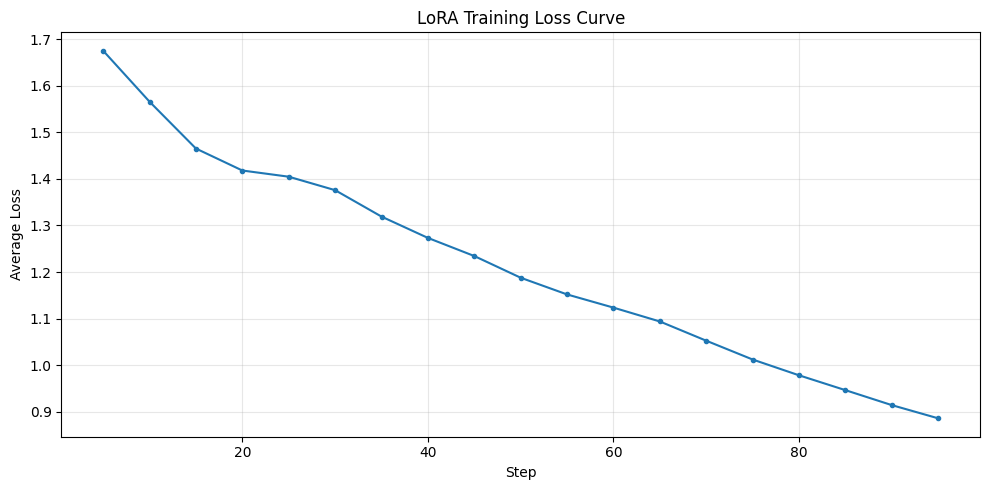

Final loss: 0.8862


In [30]:
import matplotlib.pyplot as plt

# logging_steps 已在训练代码中定义为 5，这里保持一致
steps = [(i + 1) * logging_steps for i in range(len(loss_history))]

plt.figure(figsize=(10, 5))
plt.plot(steps, loss_history, marker="o", markersize=3, linewidth=1.5)
plt.xlabel("Step")
plt.ylabel("Average Loss")
plt.title("LoRA Training Loss Curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Final loss: {loss_history[-1]:.4f}")

## 评估

In [31]:
def inference(
    model,
    tokenizer,
    text: str, # 输入的提示文本
    max_new_tokens: int = 160, # 最多生成多少个新 token
    do_sample: bool = True, # 是否随机采样（True =多样性, False =贪婪）
    temperature: float = 0.3,
    print_inputs: bool = True,
    streaming: bool = False,
):
    # 构建输入
    prompt_msg = [
        {"role": "user", "content": text}
    ]
    prompt = tokenizer.apply_chat_template(prompt_msg, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors='pt', add_special_tokens=False).to(device)
    input_ids = inputs['input_ids']
    im_end_id = tokenizer.encode("<|im_end|>")[0]

    # 是否打印输入部分
    if print_inputs:
        print(prompt, end='')

    # 生成
    stop_words = [tokenizer.eos_token_id, im_end_id]
    generated_tokens = []

    for _ in range(max_new_tokens):
        with torch.no_grad():
            outputs = model(input_ids)

        logits = outputs.logits[:, -1, :]

        # 不同采样方式
        if do_sample:
            logits = logits / temperature
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
        else:
            # 贪婪解码
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
        if next_token.item() in stop_words:
            break
        generated_tokens.append(next_token.item())
        # 流式输出
        if streaming:
            yield tokenizer.decode(generated_tokens)

        # 更新输入
        input_ids = torch.cat([input_ids, next_token], dim=-1)

    generated_text = tokenizer.decode(generated_tokens)
    return generated_text

In [32]:
model.eval() # 设为评估模式，关闭训练行为

# 测试问题列表
for test_text in [
    'Describe the process of bacterial conjugation and its significance in the context of antibiotic resistance.',
    'Explain the role of insulin in the body and how insulin resistance affects blood sugar levels.',
    'Provide recommendations for lifestyle changes that can help improve the overall health of a patient with type 2 diabetes.',
]:
    print('=' * 80)
    last_text = ''
    for text in inference(model, tokenizer, test_text, streaming=True):
        cur_text = text.replace(last_text, '')
        print(cur_text, end='', flush=True)
        last_text = text
    print('\n')

<|im_start|>system
You are a helpful assistant<|im_end|>
<|im_start|>user
Describe the process of bacterial conjugation and its significance in the context of antibiotic resistance.<|im_end|>
<|im_start|>assistant
Bacterial conjugation is a process by which bacteria exchange genetic material, usually by forming a type-2 cell, through direct contact. The process involves two bacteria, each with a unique plasmid, which is then transferred to each other. The recipient bacteria then receives the genetic material from the source bacteria, and the process repeats itself, producing a new, genetically diverse population. This process is significant in antibiotic resistance because it allows bacteria to evolve and develop resistance to certain antibiotics, while also providing a source of genetic variation that may contribute to antibiotic resistance.

<|im_start|>system
You are a helpful assistant<|im_end|>
<|im_start|>user
Explain the role of insulin in the body and how insulin resistance aff

# TODO

## 1. 消融实验（Ablation Study）
这是最直接的后续实验，帮助你理解 LoRA 各组件的作用：

- 不同 rank 对比 ： r=1, 2, 4, 8, 16, 32, 64 ，记录 loss 曲线和最终效果，观察 rank 与性能的关系
- 不同 alpha 对比 ：固定 r=8，改变 alpha 看缩放系数的影响
- 不同 target module 对比 ：只对 attention 的 Q/K/V 加 LoRA vs 全线性层 vs 只对 MLP 加
- 对比 Full Fine-tuning ：在你的 tiny llama 上跑全量微调，对比 LoRA 的效率和效果

## 2. LoRA 权重分析
深入理解 LoRA 学到了什么：

- 奇异值分析 ：对学到的 ΔW = B @ A 做 SVD 分解，看不同层的有效秩
- 层间差异可视化 ：哪些层的 LoRA 权重变化最大？attention 层和 MLP 层有什么不同？
- 与预训练权重的相似度 ：计算 cosine_similarity(W₀, ΔW) ，分析 LoRA 是增强了原方向还是引入了新方向

## 3. LoRA 变体实现
在你现有代码基础上实现论文中的改进：

- DoRA （Weight-Decomposed Low-Rank Adaptation）：将预训练权重分解为 magnitude + direction，只对 direction 做低秩更新。这是目前效果最好的 LoRA 变体之一。
- LoRA+ ：给 lora_A 和 lora_B 设置不同的学习率（λ_B / λ_A ≈ 2^r），训练更高效。
- AdaLoRA ：自适应分配不同层的 rank，重要的层给更高的 rank。

## 4. 多 Adapter 实验
LoRA 的一大优势是"插件式"部署：

- 在 bioinstruct 上训练一个 adapter，再在其他数据集（如 math、code）上各训练一个
- 实现 adapter 切换 ：同一个 base model 加载不同 adapter 完成不同任务
- 尝试 adapter 融合 ：对两个 adapter 的权重做线性插值，观察效果变化

## 5. 训练技巧补充
- 学习率调度器 ：加入 cosine/linear warmup scheduler，对比有无 scheduler 的效果
- 混合精度训练 ：用 torch.cuda.amp.autocast + GradScaler 加速训练
- 梯度累积 ：模拟更大 batch size（当显存不够时很实用）
- 与 PEFT 库对比 ：用 HuggingFace PEFT 库实现同样的 LoRA，对比你的实现

## 6. QLoRA 实验
在 LoRA 基础上加量化，这是实际部署中非常重要的技术：

- 用 bitsandbytes 把 base model 量化为 4-bit（NF4）
- 对比 QLoRA vs LoRA 的显存占用和训练速度
- 理解双重量化（Double Quantization）的作用

## 7. 评估体系完善
目前只有 loss，可以加入：

- Perplexity 计算（在验证集上）
- ROUGE/BLEU 等生成质量指标
- 在生物医学 QA 任务上的 accuracy 评估
- 画出 loss 曲线和 eval metric 曲线

# Reference

https://github.com/Mxoder/LLM-from-scratch